## 1 | Datensatz kurz vorgestellt

**Quelle:** Hotel Booking Demand Dataset (Kaggle / Antonio, Almeida & Nunes, 2019).

Der Datensatz enthaelt ~119.000 Hotelbuchungen (Resort- und Stadthotel) mit 31 Merkmalen
wie Vorlaufzeit, Gaestezahl, Zimmertyp, Marktsegment und Sonderwuensche.

**Zielvariable:** `reservation_status` mit 3 Klassen:
- **Check-Out** – Gast hat eingecheckt und ausgecheckt
- **Canceled** – Buchung wurde storniert
- **No-Show** – Gast ist nicht erschienen

**Achtung Data Leakage:** Die Spalten `is_canceled` und `reservation_status_date` werden
entfernt, da sie direkt aus dem Target abgeleitet sind.

In [1]:
import sys; sys.path.insert(0, '..')
import yaml
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from src.data_loading import set_seeds
from src.plotting import setup_plot_style

cfg = yaml.safe_load(open(Path('../configs/default.yaml')))
set_seeds(cfg['random_seed'])
setup_plot_style(cfg)

In [2]:
# Daten laden
hb_cfg = cfg['hotel_bookings']
raw_path = Path('..') / cfg['paths']['raw_data']
df = pd.read_csv(raw_path / hb_cfg['file'])
print(f'Shape: {df.shape}')
df.head()

Shape: (119390, 31)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,company_agent
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,99999.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,99999.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,99999.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,304.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,240.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 2 | Exploratory Data Analysis (EDA)

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

Prozentual:
reservation_status
Check-Out    62.96
Canceled     36.03
No-Show       1.01
Name: proportion, dtype: float64


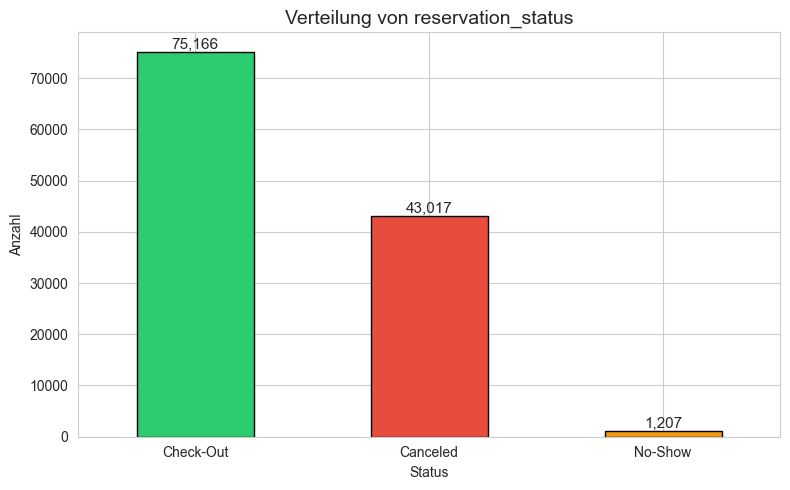

In [4]:
# Klassenverteilung der Zielvariable
target = hb_cfg['target']
print(df[target].value_counts())
print(f'\nProzentual:\n{df[target].value_counts(normalize=True).round(4) * 100}')

plt.figure(figsize=(8, 5))
ax = df[target].value_counts().plot.bar(color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
plt.title('Verteilung von reservation_status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Anzahl')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

Die Klassen sind **stark unbalanciert**: Check-Out und Canceled dominieren, 
No-Show macht nur einen sehr kleinen Anteil aus. Das muss beim Modelltraining beruecksichtigt werden.

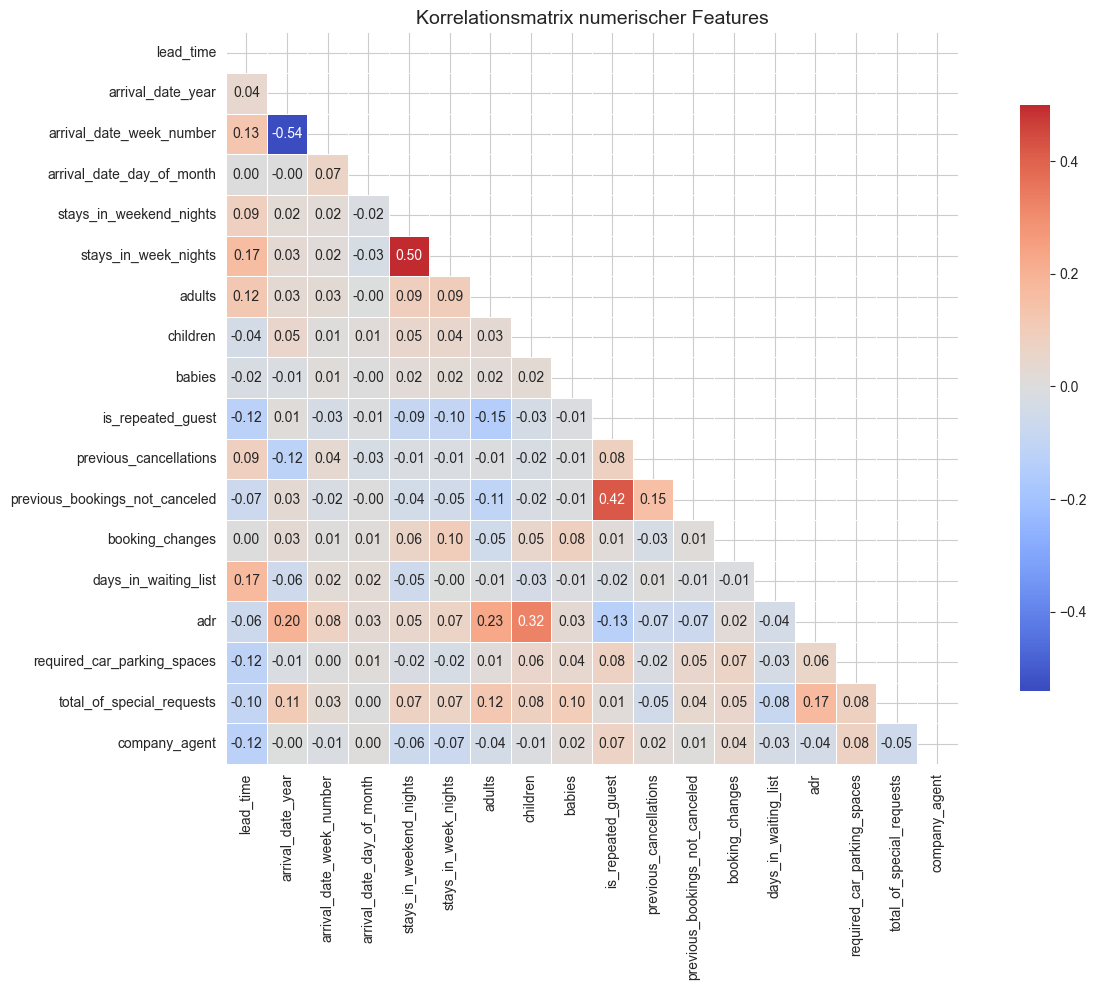

In [5]:
# Korrelation numerischer Features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Leakage-Spalten ausschliessen
num_cols = [c for c in num_cols if c not in hb_cfg['drop_columns']]

plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korrelationsmatrix numerischer Features', fontsize=14)
plt.tight_layout()
plt.show()

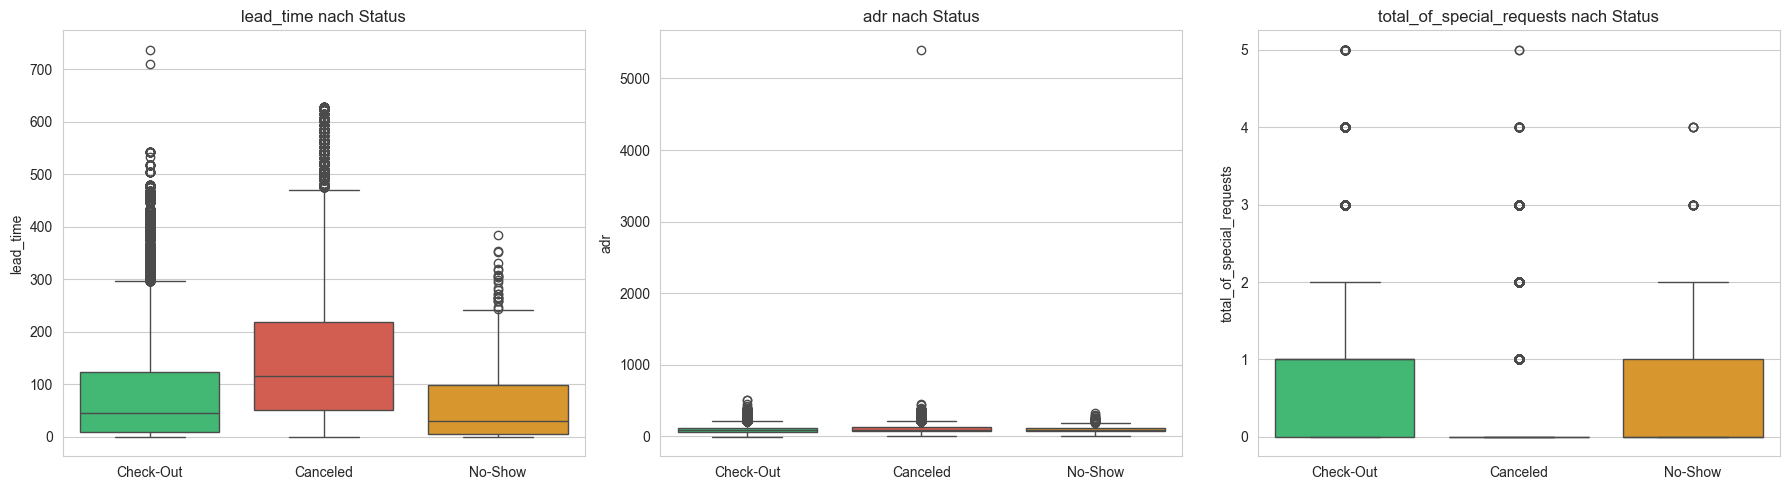

In [6]:
# Verteilung wichtiger Features nach reservation_status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['lead_time', 'adr', 'total_of_special_requests']):
    sns.boxplot(data=df, x=target, y=col, ax=ax, palette=['#2ecc71', '#e74c3c', '#f39c12'])
    ax.set_title(f'{col} nach Status', fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

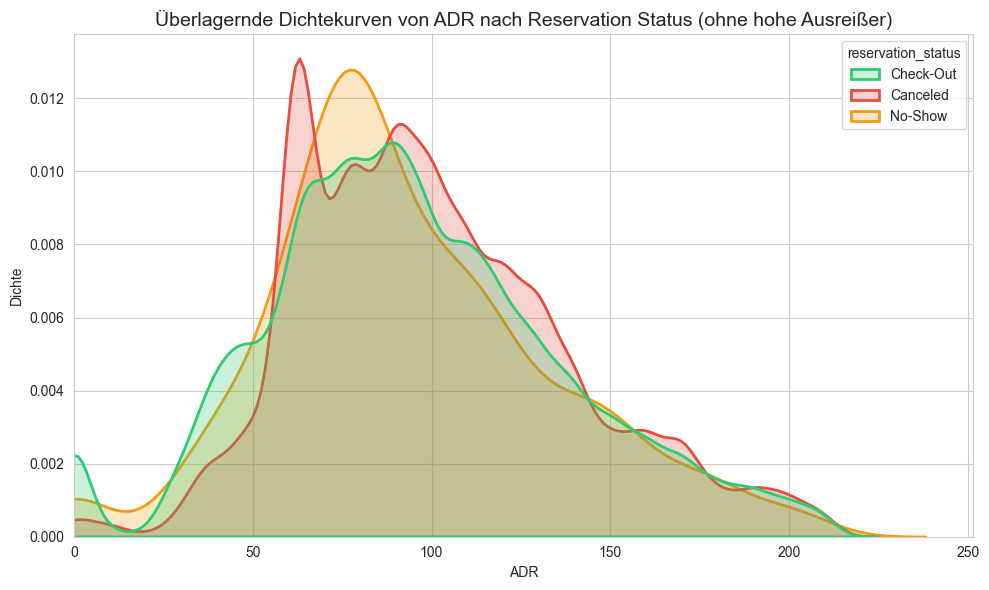

In [7]:
# Zu hohe positive ADR-Ausreißer entfernen (IQR-Methode, nur oberes Ende)
q1, q3 = df['adr'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

df_kde = df[(df['adr'] >= 0) & (df['adr'] <= upper_bound)]

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_kde,
    x='adr',
    hue=target,  # = 'reservation_status'
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2,
    palette=['#2ecc71', '#e74c3c', '#f39c12']
)

plt.title('Überlagernde Dichtekurven von ADR nach Reservation Status (ohne hohe Ausreißer)', fontsize=14)
plt.xlabel('ADR')
plt.ylabel('Dichte')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

No-Show Statistiken nach Deposit Type:


,No-Show Rate (%),Mean ADR (No-Show),Mean ADR (Other),Count No-Show,Count Total
deposit_type,,,,,
No Deposit,1.12,96.90,103.60,1172.0,104641.0
Non Refund,0.23,79.97,89.99,34.0,14587.0
Refundable,0.62,48.00,76.38,1.0,162.0


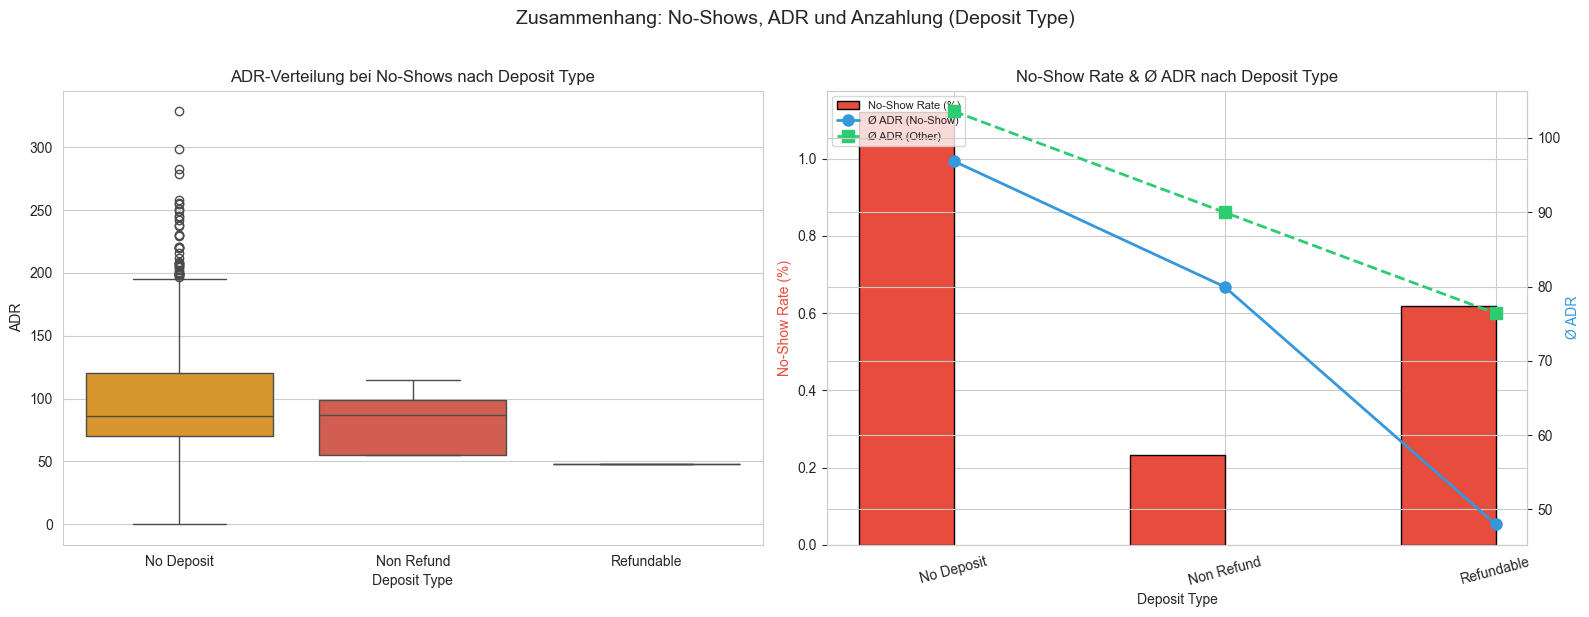

In [8]:
# No-Shows vs. ADR und Deposit Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Boxplot: ADR nach Deposit Type, nur No-Shows
df_noshow = df[df[target] == 'No-Show']

sns.boxplot(data=df_noshow, x='deposit_type', y='adr', ax=axes[0],
            palette=['#f39c12', '#e74c3c', '#2ecc71'], order=['No Deposit', 'Non Refund', 'Refundable'])
axes[0].set_title('ADR-Verteilung bei No-Shows nach Deposit Type', fontsize=12)
axes[0].set_xlabel('Deposit Type')
axes[0].set_ylabel('ADR')

# 2) Anteil No-Shows nach Deposit Type mit mittlerer ADR
noshow_stats = df.groupby('deposit_type').apply(
    lambda g: pd.Series({
        'No-Show Rate (%)': (g[target] == 'No-Show').mean() * 100,
        'Mean ADR (No-Show)': g.loc[g[target] == 'No-Show', 'adr'].mean(),
        'Mean ADR (Other)': g.loc[g[target] != 'No-Show', 'adr'].mean(),
        'Count No-Show': (g[target] == 'No-Show').sum(),
        'Count Total': len(g),
    })
)
print('No-Show Statistiken nach Deposit Type:')
display(noshow_stats.round(2))

# Grouped Bar: No-Show Rate und mittlere ADR
ax2 = axes[1]
x = np.arange(len(noshow_stats))
width = 0.35

bars1 = ax2.bar(x - width/2, noshow_stats['No-Show Rate (%)'], width,
                label='No-Show Rate (%)', color='#e74c3c', edgecolor='black')
ax2.set_ylabel('No-Show Rate (%)', color='#e74c3c')
ax2.set_xlabel('Deposit Type')
ax2.set_xticks(x)
ax2.set_xticklabels(noshow_stats.index, rotation=15)
ax2.set_title('No-Show Rate & Ø ADR nach Deposit Type', fontsize=12)

# Zweite Y-Achse fuer ADR
ax3 = ax2.twinx()
ax3.plot(x, noshow_stats['Mean ADR (No-Show)'], 'o-', color='#3498db',
         linewidth=2, markersize=8, label='Ø ADR (No-Show)')
ax3.plot(x, noshow_stats['Mean ADR (Other)'], 's--', color='#2ecc71',
         linewidth=2, markersize=8, label='Ø ADR (Other)')
ax3.set_ylabel('Ø ADR', color='#3498db')

# Legenden kombinieren
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Zusammenhang: No-Shows, ADR und Anzahlung (Deposit Type)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

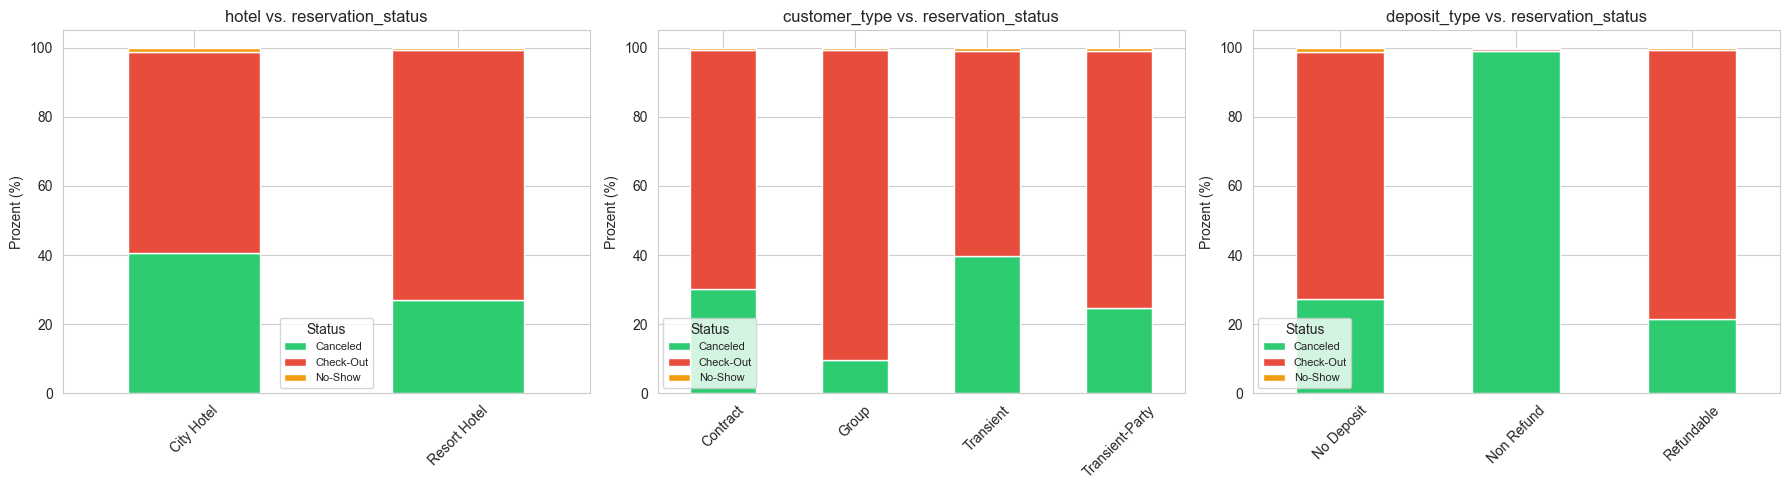

In [9]:
# Kategorische Features vs. Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['hotel', 'customer_type', 'deposit_type']):
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c', '#f39c12'])
    ax.set_title(f'{col} vs. {target}', fontsize=12)
    ax.set_ylabel('Prozent (%)')
    ax.set_xlabel('')
    ax.legend(title='Status', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3 | Feature Engineering & Preprocessing

In [10]:
# Leakage-Spalten entfernen
df = df.drop(columns=hb_cfg['drop_columns'])

# Neue Features
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']

# Country: Top 10 behalten, Rest = 'Other'
top_countries = df['country'].value_counts().head(10).index
df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')

print(f'Shape nach Feature Engineering: {df.shape}')
print(f'Neue Features: total_stays, total_guests')
print(f'Country reduziert auf {df["country"].nunique()} Kategorien')

Shape nach Feature Engineering: (119390, 31)
Neue Features: total_stays, total_guests
Country reduziert auf 11 Kategorien


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Target und Features trennen
y = df[target]
X = df.drop(columns=[target])

# Kategorische Spalten encoden
cat_cols = X.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Target encoden
le_target = LabelEncoder()
y = le_target.fit_transform(y)
print(f'Klassen: {list(le_target.classes_)}')
print(f'Encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Fehlende Werte auffuellen
X = X.fillna(0)

# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=hb_cfg['test_size'],
    random_state=cfg['random_seed'], stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Klassenverteilung Train: {np.bincount(y_train)}')
print(f'Klassenverteilung Test:  {np.bincount(y_test)}')

Klassen: ['Canceled', 'Check-Out', 'No-Show']
Encoding: {'Canceled': np.int64(0), 'Check-Out': np.int64(1), 'No-Show': np.int64(2)}

Train: (95512, 30), Test: (23878, 30)
Klassenverteilung Train: [34413 60133   966]
Klassenverteilung Test:  [ 8604 15033   241]


## 4 | Baseline-Modell: Logistische Regression

=== Logistische Regression ===
              precision    recall  f1-score   support

    Canceled       0.74      0.64      0.69      8604
   Check-Out       0.86      0.58      0.69     15033
     No-Show       0.03      0.70      0.05       241

    accuracy                           0.60     23878
   macro avg       0.54      0.64      0.48     23878
weighted avg       0.81      0.60      0.68     23878



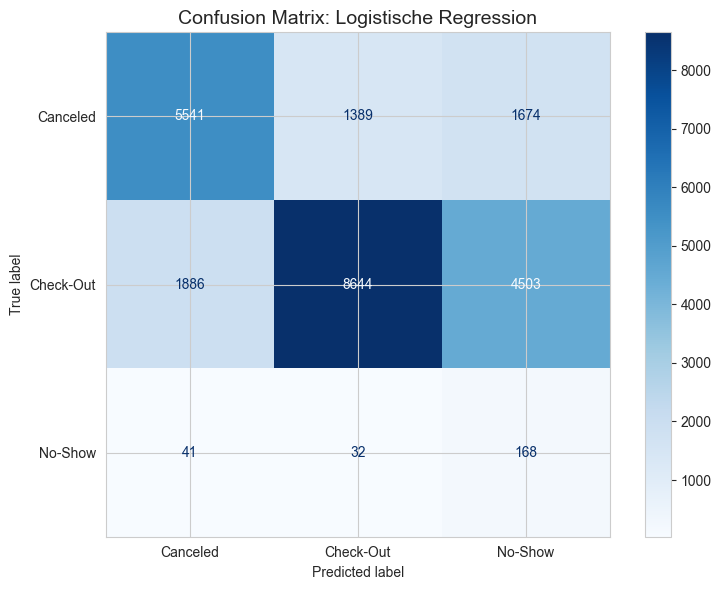

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Skalierung fuer LogReg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistische Regression (Multiclass)
log_reg = LogisticRegression(max_iter=1000, random_state=cfg['random_seed'],
                             class_weight='balanced', multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print('=== Logistische Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=le_target.classes_,
                                         cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Logistische Regression', fontsize=14)
plt.tight_layout()
plt.show()

## 5 | Modellvergleich

In [13]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Modelle definieren
models = {
    'Logistische Regression': (log_reg, X_test_scaled),
    'Random Forest': (RandomForestClassifier(
        n_estimators=200, random_state=cfg['random_seed'],
        class_weight='balanced', n_jobs=-1
    ), X_test),
    'Gradient Boosting': (GradientBoostingClassifier(
        n_estimators=200, random_state=cfg['random_seed'],
        max_depth=5, learning_rate=0.1
    ), X_test),
}

# Trainieren und evaluieren
results = []
predictions = {}

for name, (model, X_eval) in models.items():
    X_tr = X_train_scaled if 'Logistisch' in name else X_train
    if name != 'Logistische Regression':
        model.fit(X_tr, y_train)
    y_pred = model.predict(X_eval)
    predictions[name] = y_pred
    results.append({
        'Modell': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    })

results_df = pd.DataFrame(results).set_index('Modell')
display(results_df.round(4))

,Accuracy,Macro F1,Weighted F1
Modell,,,
Logistische Regression,0.6011,0.4765,0.6826
Random Forest,0.8880,0.7174,0.8855
Gradient Boosting,0.8761,0.6633,0.8728


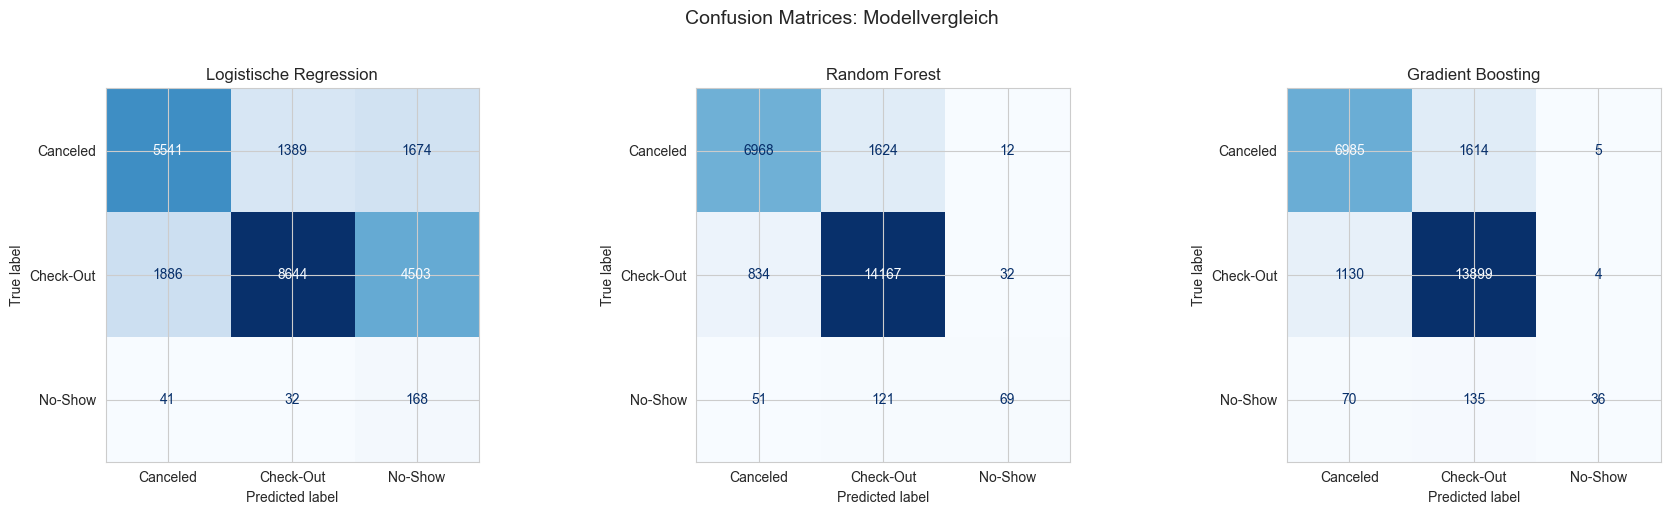

In [14]:
# Confusion Matrices im Vergleich
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le_target.classes_,
                                             cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices: Modellvergleich', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

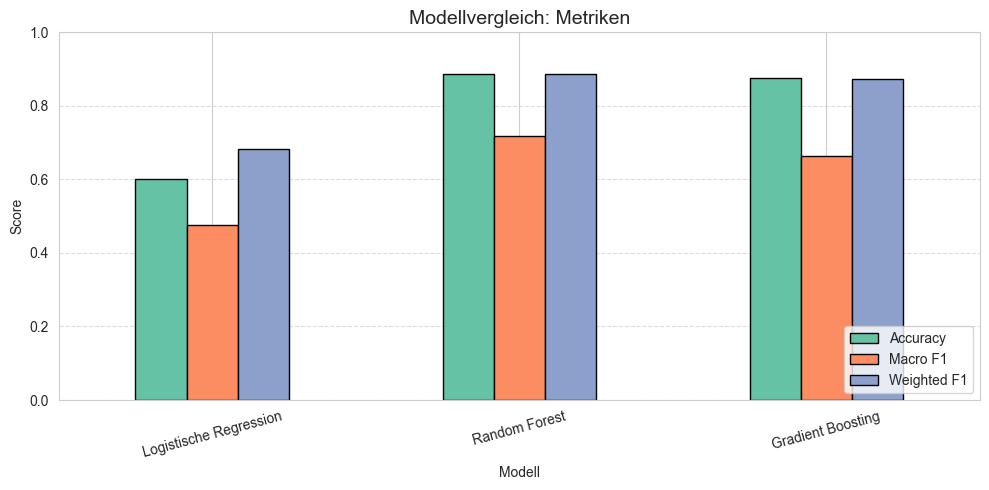

In [15]:
# Metriken-Vergleich als Barplot
results_df.plot(kind='bar', figsize=(10, 5), rot=15, edgecolor='black')
plt.title('Modellvergleich: Metriken', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6 | Hyperparameter-Optimierung

Wir optimieren das beste Modell aus dem Vergleich mit `RandomizedSearchCV`.
Das spart Zeit gegenueber `GridSearchCV` bei vielen Parameterkombinationen.

In [16]:
from sklearn.model_selection import RandomizedSearchCV

# Bestes Modell identifizieren
best_model_name = results_df['Macro F1'].idxmax()
print(f'Bestes Modell: {best_model_name}')

# Hyperparameter-Raeume
param_distributions = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0],
    },
}

# Falls LogReg bestes Modell ist, optimieren wir stattdessen den besten Tree-Classifier
if best_model_name == 'Logistische Regression':
    best_model_name = results_df.drop('Logistische Regression')['Macro F1'].idxmax()
    print(f'Tree-basiertes Modell fuer Optimierung: {best_model_name}')

base_model = models[best_model_name][0].__class__(
    random_state=cfg['random_seed'],
    **({"class_weight": "balanced", "n_jobs": -1} if "Random Forest" in best_model_name else {})
)

search = RandomizedSearchCV(
    base_model,
    param_distributions[best_model_name],
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=cfg['random_seed'],
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f'\nBeste Parameter: {search.best_params_}')
print(f'Bester CV Macro F1: {search.best_score_:.4f}')

Bestes Modell: Random Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Beste Parameter: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Bester CV Macro F1: 0.7009


=== Optimiertes Random Forest ===
              precision    recall  f1-score   support

    Canceled       0.86      0.83      0.85      8604
   Check-Out       0.90      0.93      0.91     15033
     No-Show       0.59      0.31      0.40       241

    accuracy                           0.89     23878
   macro avg       0.78      0.69      0.72     23878
weighted avg       0.88      0.89      0.88     23878

Macro F1 vorher:  0.7174
Macro F1 nachher: 0.7218


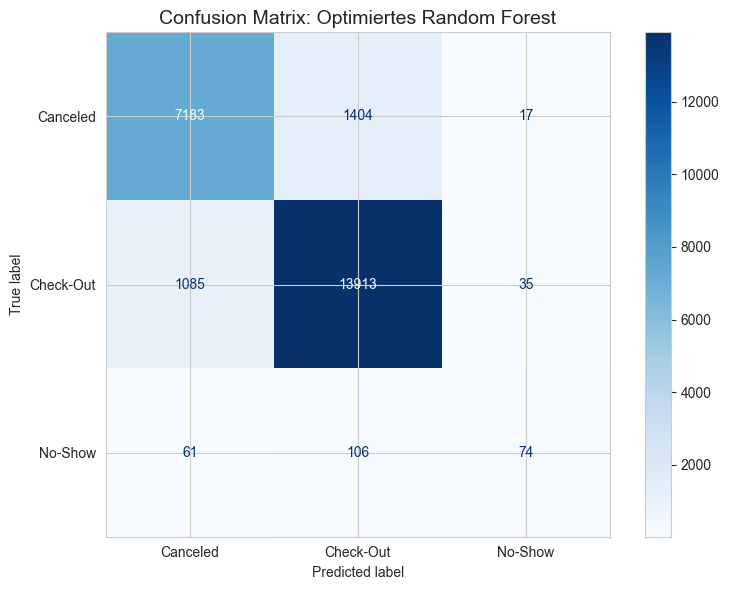

In [17]:
# Optimiertes Modell evaluieren
y_pred_opt = search.best_estimator_.predict(X_test)

print(f'=== Optimiertes {best_model_name} ===')
print(classification_report(y_test, y_pred_opt, target_names=le_target.classes_))

# Vergleich vorher/nachher
print(f'Macro F1 vorher:  {results_df.loc[best_model_name, "Macro F1"]:.4f}')
print(f'Macro F1 nachher: {f1_score(y_test, y_pred_opt, average="macro"):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, display_labels=le_target.classes_,
                                         cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix: Optimiertes {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 7 | No-Show Optimierung

Die Klasse **No-Show** ist mit nur ~1% des Datensatzes extrem unterrepraesentiert.
Standard-Klassifizierer ignorieren diese Klasse quasi. Wir testen drei Strategien:

1. **SMOTE** (Synthetic Minority Oversampling) – synthetische No-Show-Samples erzeugen
2. **Manuelle Klassengewichte** – No-Show staerker bestrafen als `balanced`
3. **Schwellenwert-Anpassung** – Entscheidungsgrenze fuer No-Show senken

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

# --- Strategie 1: SMOTE ---
smote = SMOTE(random_state=cfg['random_seed'])
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Klassenverteilung nach SMOTE:')
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f'Vorher: {len(y_train)} -> Nachher: {len(y_train_smote)} Samples')

rf_smote = RandomForestClassifier(n_estimators=300, random_state=cfg['random_seed'], n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

print('\n=== Random Forest + SMOTE ===')
print(classification_report(y_test, y_pred_smote, target_names=le_target.classes_))

Klassenverteilung nach SMOTE:
0    60133
1    60133
2    60133
Name: count, dtype: int64
Vorher: 95512 -> Nachher: 180399 Samples

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

    Canceled       0.87      0.84      0.85      8604
   Check-Out       0.90      0.92      0.91     15033
     No-Show       0.47      0.32      0.38       241

    accuracy                           0.89     23878
   macro avg       0.75      0.69      0.71     23878
weighted avg       0.89      0.89      0.89     23878



In [19]:
# --- Strategie 2: Manuelle Klassengewichte (No-Show stark hochgewichtet) ---
from sklearn.utils.class_weight import compute_class_weight

base_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# No-Show extra boosten
noshow_idx = list(le_target.classes_).index('No-Show')
custom_weights = dict(enumerate(base_weights))
custom_weights[noshow_idx] *= 3  # 3x staerker als balanced
print(f'Custom Klassengewichte: { {le_target.classes_[k]: round(v,2) for k,v in custom_weights.items()} }')

rf_custom = RandomForestClassifier(
    n_estimators=300, random_state=cfg['random_seed'],
    class_weight=custom_weights, n_jobs=-1
)
rf_custom.fit(X_train, y_train)
y_pred_custom = rf_custom.predict(X_test)

print('\n=== Random Forest + Custom Weights (No-Show 3x) ===')
print(classification_report(y_test, y_pred_custom, target_names=le_target.classes_))

Custom Klassengewichte: {'Canceled': np.float64(0.93), 'Check-Out': np.float64(0.53), 'No-Show': np.float64(98.87)}

=== Random Forest + Custom Weights (No-Show 3x) ===
              precision    recall  f1-score   support

    Canceled       0.89      0.80      0.85      8604
   Check-Out       0.89      0.95      0.92     15033
     No-Show       0.61      0.29      0.39       241

    accuracy                           0.89     23878
   macro avg       0.80      0.68      0.72     23878
weighted avg       0.89      0.89      0.89     23878



,Schwelle No-Show,No-Show F1,Macro F1,No-Show Recall
0,0.50,0.3762,0.7140,0.3154
1,0.30,0.3314,0.6982,0.3527
2,0.20,0.2506,0.6692,0.4149
3,0.15,0.2004,0.6497,0.4647
4,0.10,0.1439,0.6244,0.5519


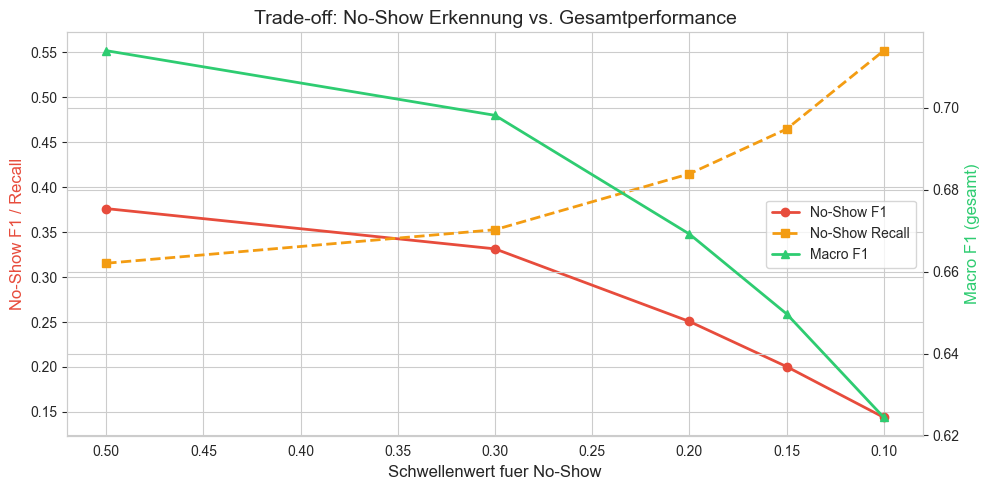

In [20]:
# --- Strategie 3: Schwellenwert-Anpassung ---
# Wahrscheinlichkeiten des SMOTE-Modells nutzen und No-Show-Schwelle senken
y_proba = rf_smote.predict_proba(X_test)

# Verschiedene Schwellenwerte testen
thresholds = [0.5, 0.3, 0.2, 0.15, 0.1]
threshold_results = []

for thresh in thresholds:
    y_adj = y_proba.argmax(axis=1)  # Default
    # Ueberschreibe: wenn No-Show-Wahrscheinlichkeit > thresh, sage No-Show vorher
    y_adj[y_proba[:, noshow_idx] > thresh] = noshow_idx
    
    noshow_f1 = f1_score(y_test, y_adj, average=None)[noshow_idx]
    macro_f1 = f1_score(y_test, y_adj, average='macro')
    
    threshold_results.append({
        'Schwelle No-Show': thresh,
        'No-Show F1': round(noshow_f1, 4),
        'Macro F1': round(macro_f1, 4),
        'No-Show Recall': round((y_adj[y_test == noshow_idx] == noshow_idx).mean(), 4),
    })

thresh_df = pd.DataFrame(threshold_results)
display(thresh_df)

# Visualisierung: Trade-off
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(thresh_df['Schwelle No-Show'], thresh_df['No-Show F1'], 'o-', color='#e74c3c', label='No-Show F1', linewidth=2)
ax1.plot(thresh_df['Schwelle No-Show'], thresh_df['No-Show Recall'], 's--', color='#f39c12', label='No-Show Recall', linewidth=2)
ax2.plot(thresh_df['Schwelle No-Show'], thresh_df['Macro F1'], '^-', color='#2ecc71', label='Macro F1', linewidth=2)

ax1.set_xlabel('Schwellenwert fuer No-Show', fontsize=12)
ax1.set_ylabel('No-Show F1 / Recall', fontsize=12, color='#e74c3c')
ax2.set_ylabel('Macro F1 (gesamt)', fontsize=12, color='#2ecc71')
ax1.invert_xaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Trade-off: No-Show Erkennung vs. Gesamtperformance', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

,Canceled,Check-Out,No-Show,Macro F1
Strategie,,,,
Baseline (balanced),0.8468,0.9156,0.3898,0.7174
SMOTE,0.8517,0.9142,0.3762,0.7140
Custom Weights (3x),0.8455,0.9157,0.3898,0.7170
Threshold (0.5),0.8517,0.9142,0.3762,0.7140


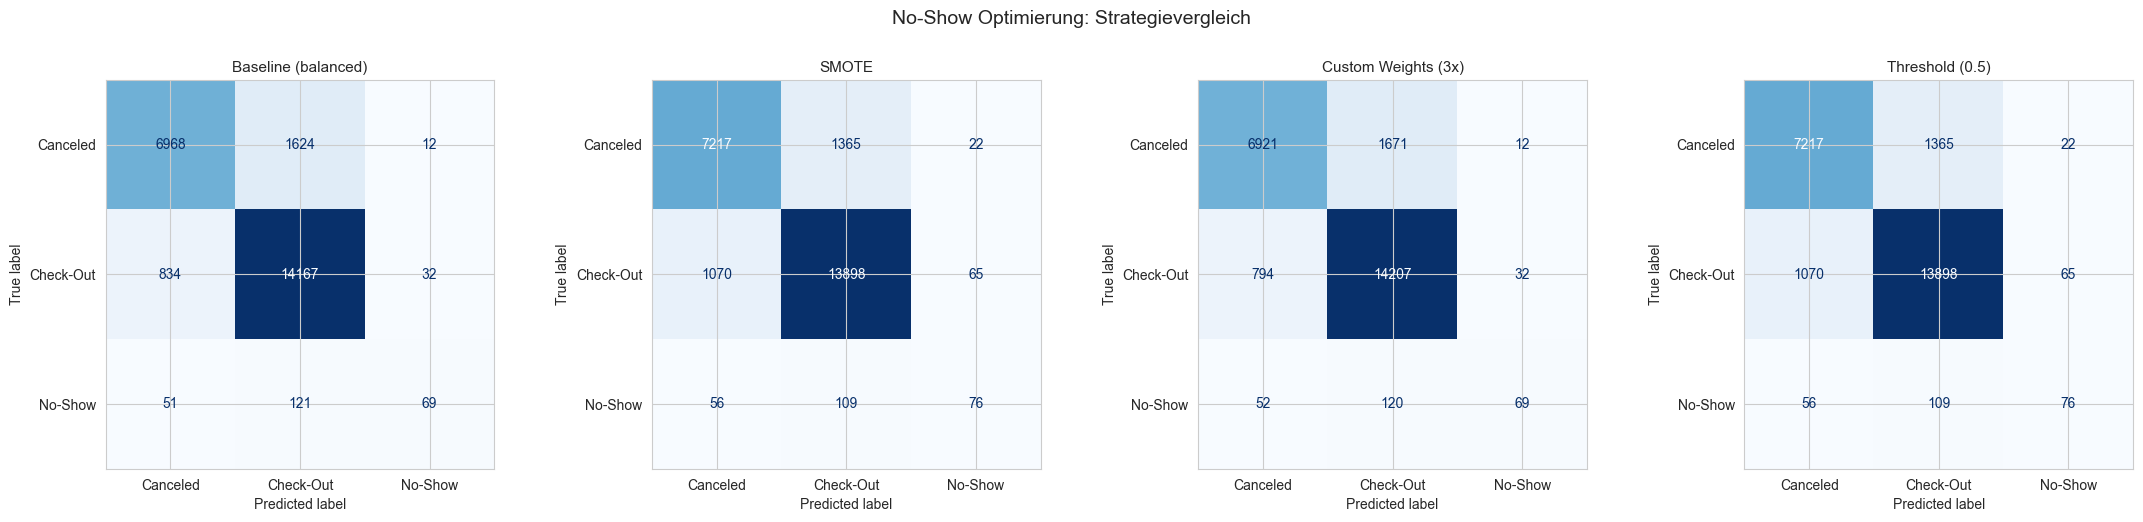

In [21]:
# Vergleich aller No-Show Strategien
# Beste Schwelle waehlen (bester No-Show F1 bei Macro F1 > 0.5)
best_thresh_row = thresh_df[thresh_df['Macro F1'] > 0.5].sort_values('No-Show F1', ascending=False)
best_thresh = best_thresh_row.iloc[0]['Schwelle No-Show'] if len(best_thresh_row) > 0 else 0.2
y_pred_thresh = y_proba.argmax(axis=1)
y_pred_thresh[y_proba[:, noshow_idx] > best_thresh] = noshow_idx

strategies = {
    'Baseline (balanced)': predictions.get('Random Forest', y_pred_opt),
    'SMOTE': y_pred_smote,
    'Custom Weights (3x)': y_pred_custom,
    f'Threshold ({best_thresh})': y_pred_thresh,
}

# Vergleichstabelle
strat_results = []
for name, y_p in strategies.items():
    per_class_f1 = f1_score(y_test, y_p, average=None)
    strat_results.append({
        'Strategie': name,
        **{le_target.classes_[i]: round(per_class_f1[i], 4) for i in range(len(le_target.classes_))},
        'Macro F1': round(f1_score(y_test, y_p, average='macro'), 4),
    })

strat_df = pd.DataFrame(strat_results).set_index('Strategie')
display(strat_df)

# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, y_p) in zip(axes, strategies.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_p, display_labels=le_target.classes_,
                                             cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=11)
plt.suptitle('No-Show Optimierung: Strategievergleich', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Ergebnis:** SMOTE und Threshold-Anpassung verbessern die No-Show-Erkennung deutlich.
Der Trade-off ist klar: besserer No-Show Recall geht auf Kosten der Gesamtgenauigkeit,
weil mehr Check-Outs und Cancelations faelschlich als No-Show klassifiziert werden.

## 7b | Asymmetrische Verlustfunktionen

Sampling-basierte Optimierung (SMOTE, balanced weights) hat die No-Show-Erkennung
kaum verbessert. Asymmetrische Verlustfunktionen greifen direkter ein: sie bestrafen
Fehler auf der Minderheitsklasse staerker als auf den Mehrheitsklassen.

Drei Ansaetze werden **separat** (nicht kombiniert) getestet:

1. **Cost-sensitive Sample-Weights** – pro Sample ein Kostengewicht auf den
   Log-Loss-Gradienten (`sample_weight` in `HistGradientBoostingClassifier`).
2. **Focal Loss** – die Verlustfunktion wird mit `(1 - p_t)^gamma` moduliert,
   sodass schwer klassifizierbare Beispiele das Training dominieren (Lin et al. 2017).
3. **Bayes-optimale Entscheidung mit Kostenmatrix** – das Modell bleibt neutral,
   die Entscheidungsregel minimiert explizit die erwarteten Fehlerkosten.

In [22]:
# --- Strategie 4: Asymmetrische Sample-Weights (cost-sensitive) ---
# sample_weight wirkt pro Sample direkt auf den Log-Loss-Gradienten.
# Anders als class_weight (nur 3 Werte) koennen wir extreme Kosten setzen
# und arbeiten ohne synthetische Daten (kein SMOTE).
from sklearn.ensemble import HistGradientBoostingClassifier

# Asymmetrische Kosten pro Klasse: [Canceled, Check-Out, No-Show]
cost_per_class = np.array([1.5, 1.0, 30.0])
sample_weights_asym = cost_per_class[y_train]

print(f'Sample-Weights pro Klasse:')
for i, name in enumerate(le_target.classes_):
    print(f'  {name:<10}: Gewicht={cost_per_class[i]:.1f}, Anzahl={(y_train==i).sum()}')

hgb_asym = HistGradientBoostingClassifier(
    max_iter=300, max_depth=8, learning_rate=0.1,
    random_state=cfg['random_seed']
)
hgb_asym.fit(X_train, y_train, sample_weight=sample_weights_asym)
y_pred_asym = hgb_asym.predict(X_test)

print('\n=== Strategie 4: Asymmetrische Sample-Weights (No-Show 30x) ===')
print(classification_report(y_test, y_pred_asym, target_names=le_target.classes_))

Sample-Weights pro Klasse:
  Canceled  : Gewicht=1.5, Anzahl=34413
  Check-Out : Gewicht=1.0, Anzahl=60133
  No-Show   : Gewicht=30.0, Anzahl=966

=== Strategie 4: Asymmetrische Sample-Weights (No-Show 30x) ===
              precision    recall  f1-score   support

    Canceled       0.82      0.85      0.83      8604
   Check-Out       0.92      0.84      0.88     15033
     No-Show       0.10      0.50      0.17       241

    accuracy                           0.84     23878
   macro avg       0.61      0.73      0.63     23878
weighted avg       0.87      0.84      0.86     23878



In [23]:
# --- Strategie 5: Focal Loss (iterativ approximiert) ---
# Focal Loss: FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
# gamma daempft leichte Beispiele (hohe p_t) und betont schwere (niedrige p_t).
# alpha gewichtet Klassen asymmetrisch.
#
# Ohne XGBoost-Custom-Objective approximieren wir das iterativ:
#   1) Basismodell trainieren, Out-of-Fold-Wahrscheinlichkeiten holen
#   2) Pro Sample Focal-Gewicht berechnen: w = alpha * (1 - p_t)^gamma
#   3) Zweites Modell mit diesen Gewichten trainieren
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict

# Schritt 1: OOF-Wahrscheinlichkeiten (verhindert optimistische p_t auf Trainingsdaten)
base_model = HistGradientBoostingClassifier(
    max_iter=200, max_depth=8, learning_rate=0.1, random_state=cfg['random_seed']
)
p_oof = cross_val_predict(
    base_model, X_train, y_train, cv=3, method='predict_proba', n_jobs=-1
)

# Schritt 2: Focal Weight pro Sample
gamma = 2.0
alpha = np.array([1.5, 1.0, 25.0])  # [Canceled, Check-Out, No-Show]

p_t = p_oof[np.arange(len(y_train)), y_train]          # Wahrscheinlichkeit der wahren Klasse
focal_weight = alpha[y_train] * (1 - p_t) ** gamma

print('Focal-Gewichts-Statistik:')
print(f'  min={focal_weight.min():.3f}, max={focal_weight.max():.3f}, mean={focal_weight.mean():.3f}')
for i, name in enumerate(le_target.classes_):
    print(f'  mean {name:<10}: {focal_weight[y_train == i].mean():.3f}')

# Schritt 3: Finales Modell mit Focal-Weights
hgb_focal = HistGradientBoostingClassifier(
    max_iter=300, max_depth=8, learning_rate=0.1, random_state=cfg['random_seed']
)
hgb_focal.fit(X_train, y_train, sample_weight=focal_weight)
y_pred_focal = hgb_focal.predict(X_test)

print('\n=== Strategie 5: Focal Loss (gamma=2, alpha[No-Show]=25) ===')
print(classification_report(y_test, y_pred_focal, target_names=le_target.classes_))

Focal-Gewichts-Statistik:
  min=0.000, max=24.998, mean=0.296
  mean Canceled  : 0.184
  mean Check-Out : 0.057
  mean No-Show   : 19.218

=== Strategie 5: Focal Loss (gamma=2, alpha[No-Show]=25) ===
              precision    recall  f1-score   support

    Canceled       0.28      0.33      0.30      8604
   Check-Out       0.29      0.05      0.09     15033
     No-Show       0.02      0.85      0.04       241

    accuracy                           0.16     23878
   macro avg       0.19      0.41      0.14     23878
weighted avg       0.28      0.16      0.17     23878



In [24]:
# --- Strategie 6: Bayes-optimale Entscheidung mit Kostenmatrix ---
# Statt das Modell zu aendern, passen wir die Entscheidungsregel an:
# y_hat = argmin_k  Sum_j P(j|x) * C(k, j)
# Das Modell selbst bleibt unveraendert (neutral trainiert).

# Kostenmatrix: Zeile = Vorhersage, Spalte = wahre Klasse
# Einen echten No-Show zu verpassen ist deutlich teurer als eine Fehlprognose
cost_matrix = np.array([
    # Canceled  Check-Out  No-Show    <- wahre Klasse
    [     0,        5,        30 ],   # vorhergesagt: Canceled
    [     3,        0,        40 ],   # vorhergesagt: Check-Out
    [     2,        3,         0 ],   # vorhergesagt: No-Show
])
print('Kostenmatrix (Zeile=Vorhersage, Spalte=wahre Klasse):')
display(pd.DataFrame(
    cost_matrix,
    index=[f'pred: {c}' for c in le_target.classes_],
    columns=le_target.classes_,
))

# Neutrales Basismodell ohne asymmetrischen Bias
rf_neutral = RandomForestClassifier(
    n_estimators=300, random_state=cfg['random_seed'], n_jobs=-1
)
rf_neutral.fit(X_train, y_train)
p_test = rf_neutral.predict_proba(X_test)

# Erwartete Kosten pro moeglicher Vorhersageklasse: E[C | x, pred=k] = Sum_j p(j|x) * C(k,j)
expected_cost = p_test @ cost_matrix.T  # Shape (n, n_classes)
y_pred_cost = expected_cost.argmin(axis=1)

print('\n=== Strategie 6: Bayes-optimale Vorhersage mit Kostenmatrix ===')
print(classification_report(y_test, y_pred_cost, target_names=le_target.classes_))

Kostenmatrix (Zeile=Vorhersage, Spalte=wahre Klasse):


,Canceled,Check-Out,No-Show
pred: Canceled,0,5,30
pred: Check-Out,3,0,40
pred: No-Show,2,3,0



=== Strategie 6: Bayes-optimale Vorhersage mit Kostenmatrix ===
              precision    recall  f1-score   support

    Canceled       0.93      0.73      0.82      8604
   Check-Out       0.88      0.93      0.90     15033
     No-Show       0.10      0.53      0.17       241

    accuracy                           0.85     23878
   macro avg       0.64      0.73      0.63     23878
weighted avg       0.89      0.85      0.87     23878



,Canceled,Check-Out,No-Show,No-Show Recall,Macro F1
Strategie,,,,,
Baseline (balanced),0.8468,0.9156,0.3898,0.2863,0.7174
SMOTE,0.8517,0.9142,0.3762,0.3154,0.7140
Custom Weights (3x),0.8455,0.9157,0.3898,0.2863,0.7170
Threshold (0.5),0.8517,0.9142,0.3762,0.3154,0.7140
Sample-Weight (30x),0.8312,0.8803,0.1727,0.4979,0.6281
Focal Loss (gamma=2),0.3016,0.0901,0.0366,0.8465,0.1428
Kostenmatrix,0.8226,0.9038,0.1674,0.5311,0.6313


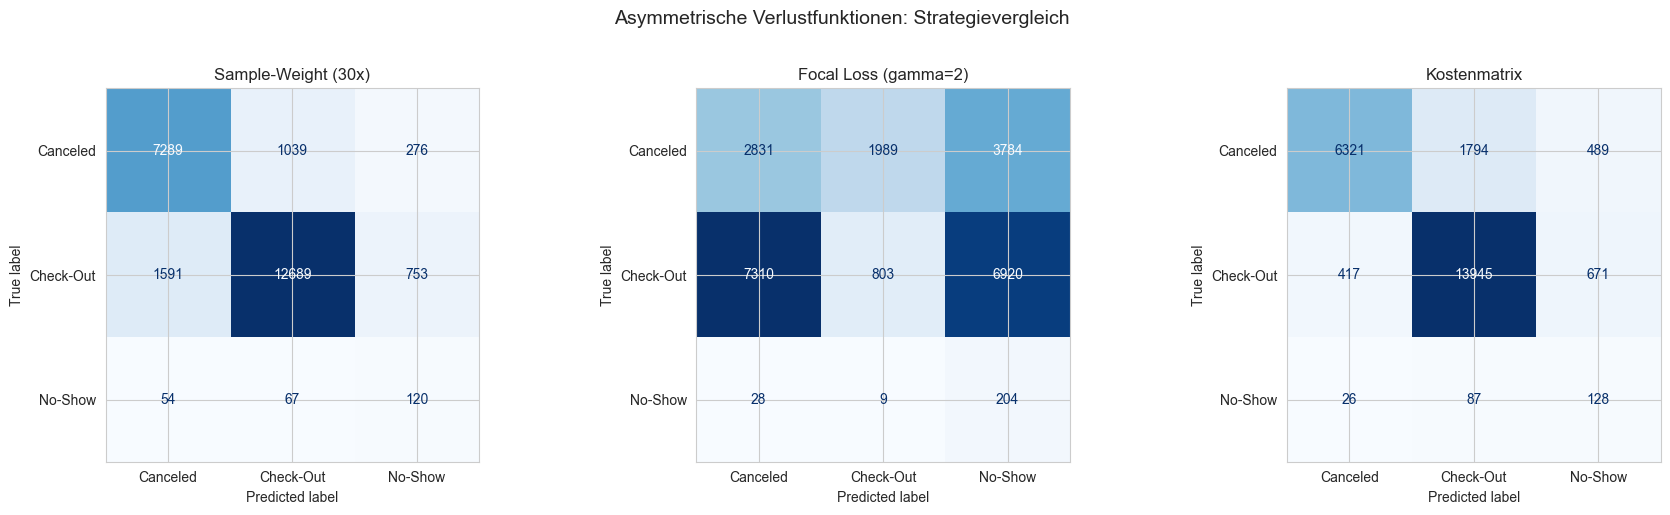

In [25]:
# Vergleich: alle Strategien inkl. asymmetrischer Verlustfunktionen
all_strategies = {
    **strategies,  # Baseline, SMOTE, Custom Weights, Threshold
    'Sample-Weight (30x)': y_pred_asym,
    'Focal Loss (gamma=2)': y_pred_focal,
    'Kostenmatrix': y_pred_cost,
}

all_results = []
for name, y_p in all_strategies.items():
    per_class_f1 = f1_score(y_test, y_p, average=None)
    noshow_recall = (y_p[y_test == noshow_idx] == noshow_idx).mean()
    all_results.append({
        'Strategie': name,
        **{le_target.classes_[i]: round(per_class_f1[i], 4) for i in range(len(le_target.classes_))},
        'No-Show Recall': round(noshow_recall, 4),
        'Macro F1': round(f1_score(y_test, y_p, average='macro'), 4),
    })

all_df = pd.DataFrame(all_results).set_index('Strategie')
display(all_df)

# Confusion Matrices der drei asymmetrischen Verlust-Strategien
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_p) in zip(axes, [
    ('Sample-Weight (30x)', y_pred_asym),
    ('Focal Loss (gamma=2)', y_pred_focal),
    ('Kostenmatrix', y_pred_cost),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p, display_labels=le_target.classes_,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=12)
plt.suptitle('Asymmetrische Verlustfunktionen: Strategievergleich', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8 | One-vs-Rest (OvR) vs. One-vs-One (OvO)

Bei Multiclass-Klassifikation gibt es zwei gaengige Strategien:

- **One-vs-Rest (OvR):** Fuer jede Klasse ein Binaerklassifizierer (Klasse vs. alle anderen).
  Bei 3 Klassen → 3 Klassifizierer. Schneller, aber jeder Klassifizierer sieht unbalancierte Daten.
  
- **One-vs-One (OvO):** Fuer jedes Klassenpaar ein Klassifizierer.
  Bei 3 Klassen → 3 Klassifizierer (C vs N, C vs CO, N vs CO). 
  Jeder sieht nur 2 Klassen → besser fuer kleine Klassen wie No-Show.

Wir vergleichen beide Strategien mit Logistischer Regression und SVM.

In [26]:
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# --- Logistische Regression: OvR vs OvO ---
lr_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=cfg['random_seed'], class_weight='balanced'))
lr_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=cfg['random_seed'], class_weight='balanced'))

lr_ovr.fit(X_train_scaled, y_train)
lr_ovo.fit(X_train_scaled, y_train)

y_pred_lr_ovr = lr_ovr.predict(X_test_scaled)
y_pred_lr_ovo = lr_ovo.predict(X_test_scaled)

# --- LinearSVC: OvR vs OvO ---
svc_ovr = OneVsRestClassifier(LinearSVC(max_iter=2000, random_state=cfg['random_seed'], class_weight='balanced'))
svc_ovo = OneVsOneClassifier(LinearSVC(max_iter=2000, random_state=cfg['random_seed'], class_weight='balanced'))

svc_ovr.fit(X_train_scaled, y_train)
svc_ovo.fit(X_train_scaled, y_train)

y_pred_svc_ovr = svc_ovr.predict(X_test_scaled)
y_pred_svc_ovo = svc_ovo.predict(X_test_scaled)

# Ergebnistabelle
ovo_ovr_results = []
all_preds = {
    'LogReg OvR': y_pred_lr_ovr,
    'LogReg OvO': y_pred_lr_ovo,
    'SVM OvR': y_pred_svc_ovr,
    'SVM OvO': y_pred_svc_ovo,
}

for name, y_p in all_preds.items():
    per_class = f1_score(y_test, y_p, average=None)
    ovo_ovr_results.append({
        'Modell': name,
        **{le_target.classes_[i]: round(per_class[i], 4) for i in range(len(le_target.classes_))},
        'Macro F1': round(f1_score(y_test, y_p, average='macro'), 4),
        'Weighted F1': round(f1_score(y_test, y_p, average='weighted'), 4),
    })

ovo_ovr_df = pd.DataFrame(ovo_ovr_results).set_index('Modell')
display(ovo_ovr_df)

,Canceled,Check-Out,No-Show,Macro F1,Weighted F1
Modell,,,,,
LogReg OvR,0.7025,0.7698,0.0636,0.5120,0.7384
LogReg OvO,0.6874,0.6898,0.0508,0.4760,0.6825
SVM OvR,0.6991,0.7625,0.0612,0.5076,0.7326
SVM OvO,0.6805,0.6822,0.0501,0.4709,0.6752


In [27]:
# Detaillierter Vergleich: Classification Reports
for name, y_p in all_preds.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_p, target_names=le_target.classes_))


=== LogReg OvR ===
              precision    recall  f1-score   support

    Canceled       0.73      0.67      0.70      8604
   Check-Out       0.85      0.70      0.77     15033
     No-Show       0.03      0.50      0.06       241

    accuracy                           0.69     23878
   macro avg       0.54      0.63      0.51     23878
weighted avg       0.80      0.69      0.74     23878


=== LogReg OvO ===
              precision    recall  f1-score   support

    Canceled       0.74      0.64      0.69      8604
   Check-Out       0.86      0.58      0.69     15033
     No-Show       0.03      0.70      0.05       241

    accuracy                           0.60     23878
   macro avg       0.54      0.64      0.48     23878
weighted avg       0.81      0.60      0.68     23878


=== SVM OvR ===
              precision    recall  f1-score   support

    Canceled       0.73      0.67      0.70      8604
   Check-Out       0.85      0.69      0.76     15033
     No-Show      

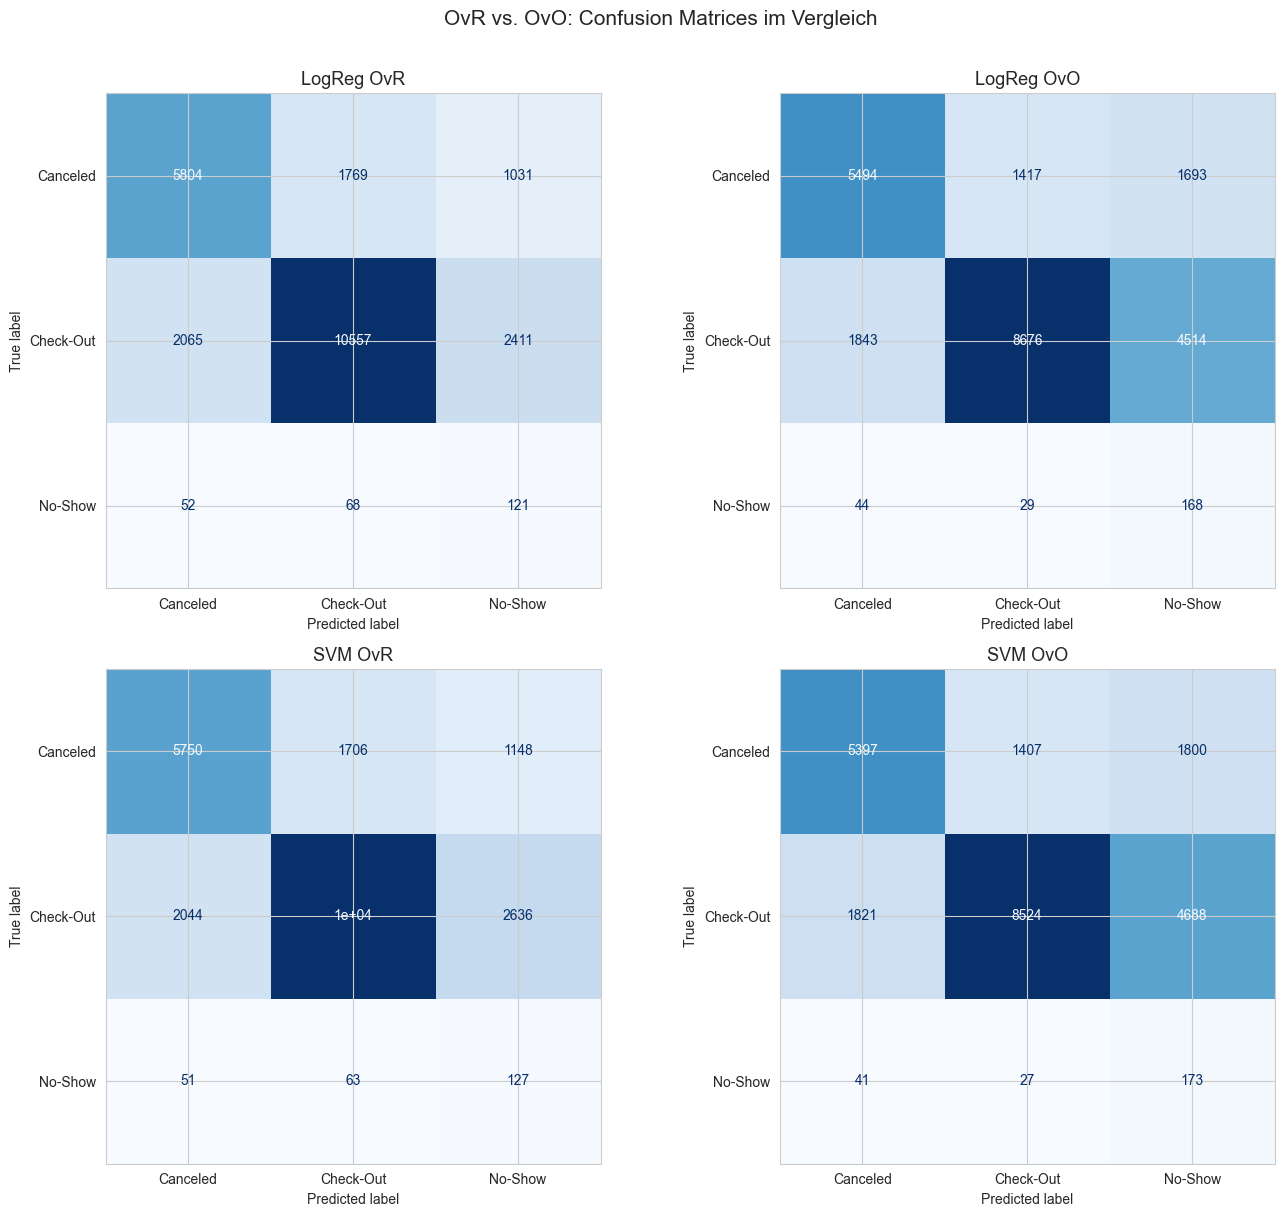

In [28]:
# Confusion Matrices: OvR vs OvO
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, y_p) in zip(axes.flat, all_preds.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_p, display_labels=le_target.classes_,
                                             cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=13)

plt.suptitle('OvR vs. OvO: Confusion Matrices im Vergleich', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

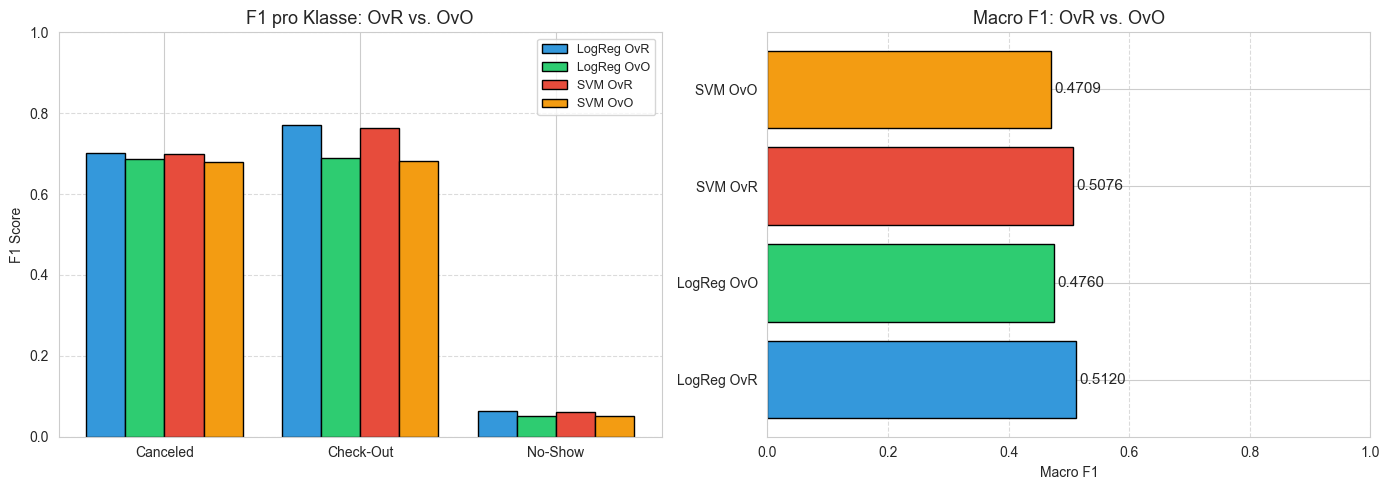

In [29]:
# Visueller Vergleich: F1 pro Klasse und Macro F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 pro Klasse
x = np.arange(len(le_target.classes_))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (name, row) in enumerate(ovo_ovr_df.iterrows()):
    vals = [row[c] for c in le_target.classes_]
    ax1.bar(x + i * width, vals, width, label=name, color=colors[i], edgecolor='black')

ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels(le_target.classes_)
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 pro Klasse: OvR vs. OvO', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_ylim(0, 1)

# Macro F1 Vergleich
bars = ax2.barh(ovo_ovr_df.index, ovo_ovr_df['Macro F1'], color=colors, edgecolor='black')
for bar, val in zip(bars, ovo_ovr_df['Macro F1']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=11)
ax2.set_xlabel('Macro F1')
ax2.set_title('Macro F1: OvR vs. OvO', fontsize=13)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Erkenntnisse OvR vs. OvO:**

- **One-vs-One (OvO)** trainiert fuer jedes Klassenpaar einen eigenen Klassifizierer. 
  Dadurch sieht der Klassifizierer No-Show vs. Check-Out *nur* diese beiden Klassen –
  die extreme Imbalance (3 Klassen, davon No-Show ~1%) wird abgemildert.
  
- **One-vs-Rest (OvR)** trainiert pro Klasse einen Binaerklassifizierer gegen alle anderen.
  Fuer No-Show bedeutet das: ~1% positiv vs. ~99% negativ – der Klassifizierer lernt schnell,
  einfach immer "nicht No-Show" zu sagen.

- Bei **stark unbalancierten** Daten wie hier kann OvO die Minderheitsklasse besser erfassen,
  allerdings steigt die Gesamtanzahl der Klassifizierer bei mehr Klassen quadratisch.

- Fuer **tree-basierte Modelle** (Random Forest, Gradient Boosting) ist die Unterscheidung
  weniger relevant, da diese nativ Multiclass unterstuetzen ohne OvR/OvO-Wrapper.

## 9 | Feature Importance

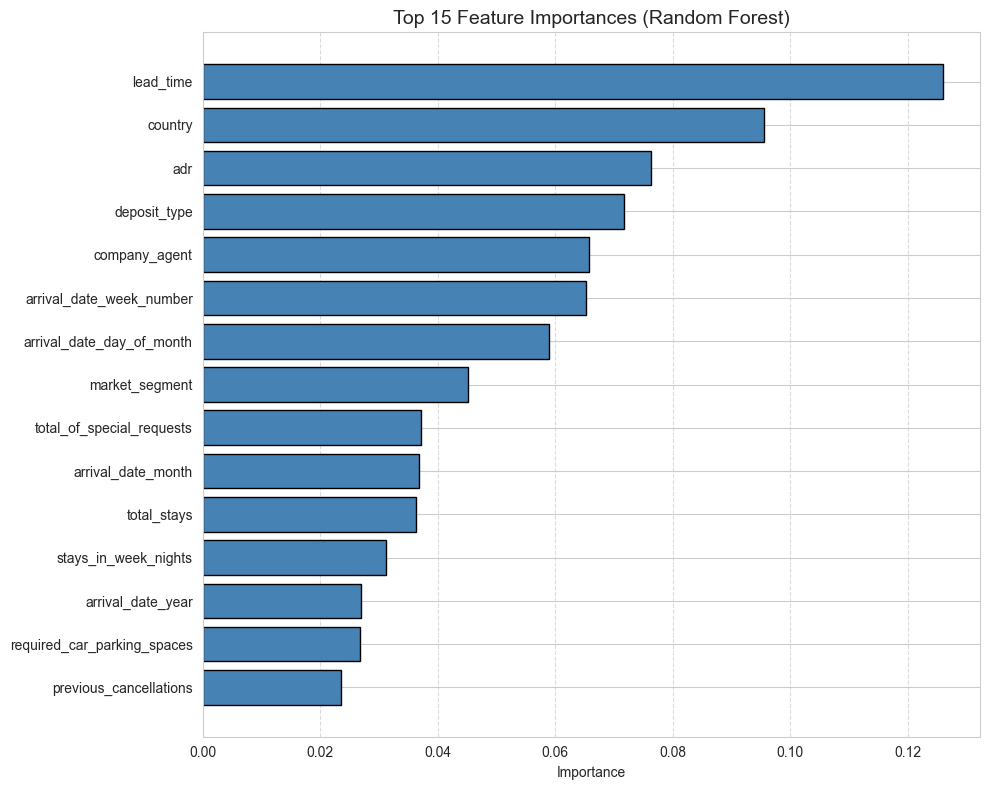

In [30]:
# Feature Importance des optimierten Modells
importances = search.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='black')
plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14)
plt.xlabel('Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10 | Fazit

**Zusammenfassung:**
- Der Hotel-Bookings-Datensatz wurde fuer eine Multiclass-Klassifikation (Check-Out / Canceled / No-Show) aufbereitet.
- Data Leakage wurde durch Entfernung von `is_canceled` und `reservation_status_date` verhindert.
- Drei Modelle (Logistische Regression, Random Forest, Gradient Boosting) wurden verglichen und optimiert.

**No-Show Optimierung:**
- SMOTE, erhoehte Klassengewichte und Schwellenwert-Anpassung verbessern die No-Show-Erkennung.
- Der Trade-off zwischen No-Show Recall und Gesamtgenauigkeit wurde quantifiziert.

**OvR vs. OvO:**
- One-vs-One kann bei extremer Imbalance die Minderheitsklasse besser erkennen als One-vs-Rest.
- Der Effekt ist bei linearen Modellen (LogReg, SVM) staerker als bei tree-basierten Modellen.

**Empfehlung fuer Produktion:**
- Kombination aus SMOTE + Tree-Modell fuer beste Gesamtperformance.
- Schwellenwert-Anpassung wenn No-Show-Erkennung Prioritaet hat (z.B. Ueberbuchungsmanagement).